In [85]:
# Khanak Agrawal_03401222025_IGDTUW

# Part A: Understanding the Dataset
# Q1. Dataset Overview
# Load the dataset and answer the following:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv("agriculture_yield_dataset.csv")

In [86]:
# How many rows and columns are present?
print("No. of Rows:", df.shape[0])
print("No. of Columns:", df.shape[1])

No. of Rows: 1500
No. of Columns: 8


In [87]:
# What are the names of all columns?
df.columns

Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')

In [88]:
# Display the first 10 records.
df.head(10)

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


In [89]:
# Q2. Data Types and Missing Values
# Check the data type of each column.

df.dtypes

,0
rainfall_mm,float64
temperature_c,float64
fertilizer_kg,float64
irrigation_hours,float64
soil_ph,float64
crop_type,object
soil_type,object
yield_ton_per_hectare,float64


In [90]:
# Identify whether any missing values are present.

df.isnull().sum()

,0
rainfall_mm,0
temperature_c,0
fertilizer_kg,0
irrigation_hours,0
soil_ph,0
crop_type,0
soil_type,0
yield_ton_per_hectare,0


In [91]:
# If missing values exist, mention the affected columns.

print(df.columns[df.isnull().any()])

Index([], dtype='object')


In [92]:
# Q3. Descriptive Statistics
# Generate summary statistics for all numerical features and answer:

print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.74000

In [93]:
# Which feature has the highest mean value?

high_mean = df.mean(numeric_only=True)
print(high_mean.idxmax(), "=", high_mean.max())

rainfall_mm = 754.0546666666667


In [94]:
# Which feature has the highest standard deviation?

high_sd = df.std(numeric_only=True)
print(high_sd.idxmax(), "=", high_sd.max())

rainfall_mm = 255.0972161445094


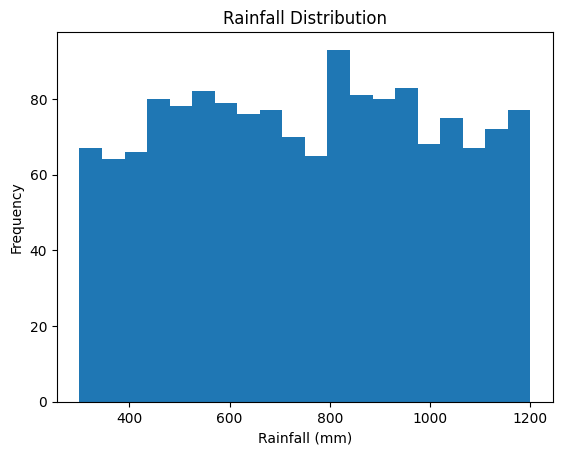

In [95]:
# Part B: Exploratory Data Analysis (EDA)
# Q4. Distribution Analysis
# Create histograms for:
# rainfall_mm

plt.hist(df['rainfall_mm'], bins = 20)
plt.title("Rainfall Distribution")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()

**Rainfall Distribution**

*   The rainfall values are spread across a certain range.
*   Most of the data appears concentrated around the middle values.
*   There are no extreme outliers, indicating balanced rainfall distribution.






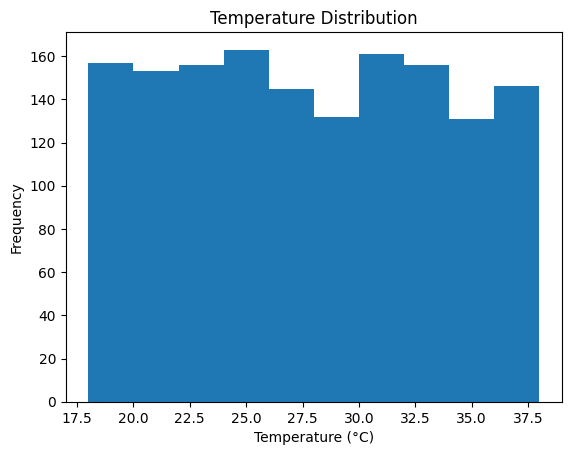

In [96]:
# temperature_c

plt.hist(df['temperature_c'])
plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

**Temperature Distribution**

*   Temperature values show a fairly uniform/normal spread.
*   Most regions fall within a moderate temperature range.
*   No extreme skewness is observed in the data.


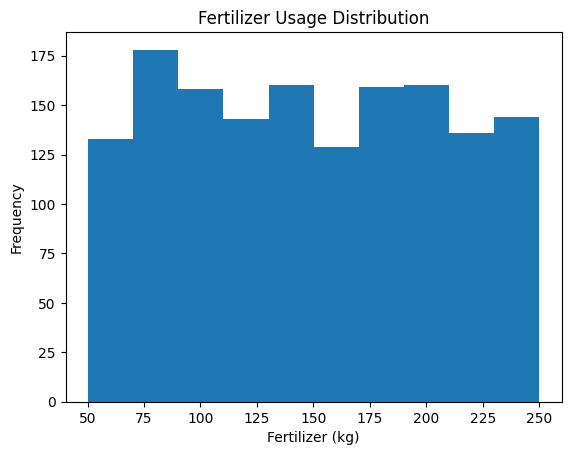

In [97]:
# fertilizer_kg

plt.hist(df['fertilizer_kg'])
plt.title("Fertilizer Usage Distribution")
plt.xlabel("Fertilizer (kg)")
plt.ylabel("Frequency")
plt.show()

**Fertilizer Usage Distribution**

*   Fertilizer usage is distributed across different levels.
*   The majority of values are clustered around average usage.
*   Very high or very low fertilizer usage is less frequent.


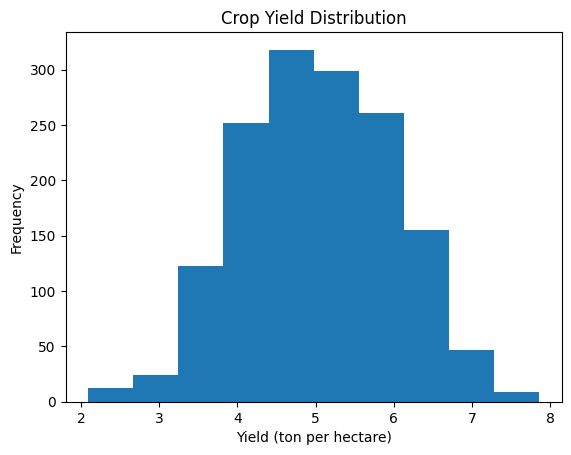

In [98]:
# yield_ton_per_hectare

plt.hist(df['yield_ton_per_hectare'])
plt.title("Crop Yield Distribution")
plt.xlabel("Yield (ton per hectare)")
plt.ylabel("Frequency")
plt.show()

**Crop Yield Distribution**

*   Crop yield values are moderately distributed.
*   Most farms achieve yields around the average range.
*   There are few extreme outliers, suggesting stable agricultural output.


In [99]:
# Q5. Crop Type Analysis
# Find the number of records for each crop type.

df['crop_type'].value_counts()

,count
crop_type,
Cotton,311
Soybean,306
Wheat,303
Rice,293
Maize,287


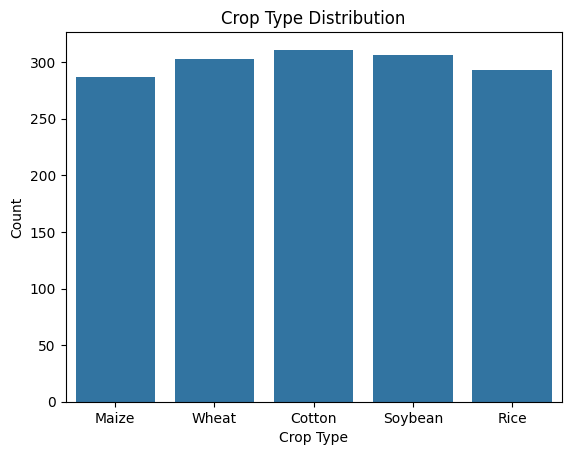

In [100]:
# Create a count plot (bar chart) for crop_type.

sns.countplot(x='crop_type', data=df)
plt.title("Crop Type Distribution")
plt.xlabel("Crop Type")
plt.ylabel("Count")
plt.show()

In [101]:
# Which crop appears most frequently?

df['crop_type'].value_counts().idxmax()

'Cotton'

In [102]:
# Q6. Soil Type Analysis
# Find the frequency of each soil type.

df['soil_type'].value_counts()

,count
soil_type,
Clay,534
Sandy,492
Loamy,474


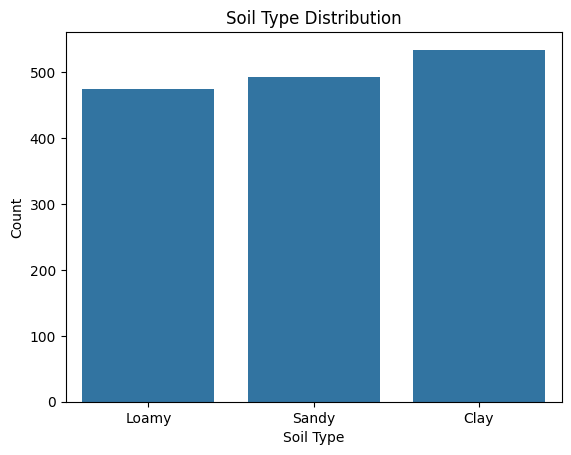

In [103]:
# Create a count plot for soil_type.

sns.countplot(x='soil_type', data=df)
plt.title("Soil Type Distribution")
plt.xlabel("Soil Type")
plt.ylabel("Count")
plt.show()

In [104]:
# Which soil type is most common?

df['soil_type'].value_counts().idxmax()

'Clay'

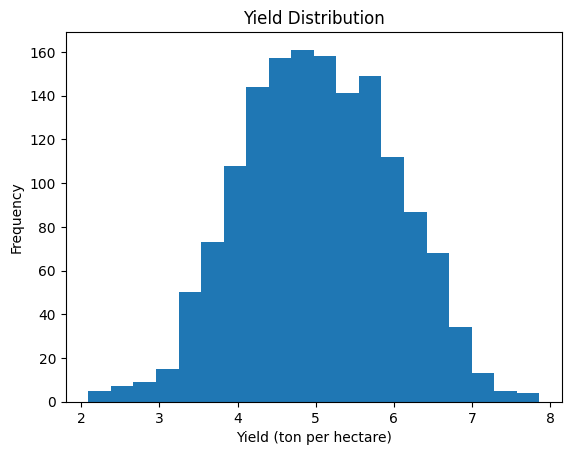

In [105]:
# Q7. Yield Distribution
# Create a histogram of yield_ton_per_hectare.

plt.hist(df['yield_ton_per_hectare'], bins=20)
plt.title("Yield Distribution")
plt.xlabel("Yield (ton per hectare)")
plt.ylabel("Frequency")
plt.show()

### **Is the distribution approximately normal?**


**Ans:** The distribution appears approximately normal as it is symmetric and follows a bell-shaped curve.

### **Are there any noticeable outliers?**

**Ans:** No significant outliers are observed, as most values are concentrated within a similar range.

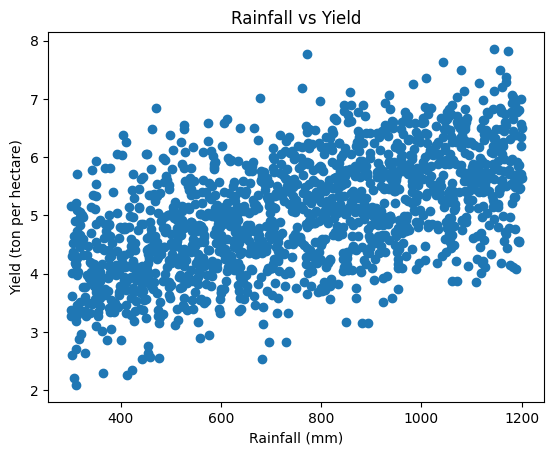

In [106]:
# Q8. Scatter Plot Analysis
# Create scatter plots of:
# 1. rainfall_mm vs yield_ton_per_hectare

plt.scatter(df['rainfall_mm'], df['yield_ton_per_hectare'])
plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (ton per hectare)")
plt.show()

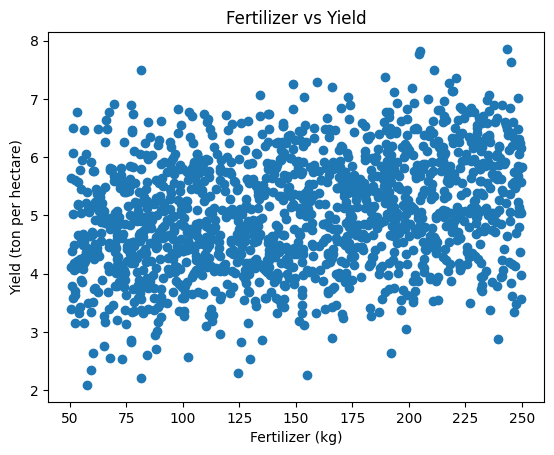

In [107]:
# 2. fertilizer_kg vs yield_ton_per_hectare

plt.scatter(df['fertilizer_kg'], df['yield_ton_per_hectare'])
plt.title("Fertilizer vs Yield")
plt.xlabel("Fertilizer (kg)")
plt.ylabel("Yield (ton per hectare)")
plt.show()

### **Based on the plots: Which feature appears to have a stronger relationship with yield?**

**Ans:** Both variables exhibit a positive relationship with yield, but rainfall shows a slightly stronger and more consistent trend. The fertilizer scatter plot is more dispersed, suggesting a weaker correlation. However, the difference between the two relationships is not very significant.

In [108]:
# Q9. Correlation Analysis
# Generate a correlation matrix for numerical features.

corr_matrix = df.corr(numeric_only=True)
corr_matrix

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
rainfall_mm,1.000000,0.026721,0.002558,0.010877,0.006916,0.553704
temperature_c,0.026721,1.000000,0.037468,0.007114,0.001513,-0.022559
fertilizer_kg,0.002558,0.037468,1.000000,-0.010497,0.010001,0.278043
irrigation_hours,0.010877,0.007114,-0.010497,1.000000,0.009307,0.542664
soil_ph,0.006916,0.001513,0.010001,0.009307,1.000000,0.024412
yield_ton_per_hectare,0.553704,-0.022559,0.278043,0.542664,0.024412,1.000000


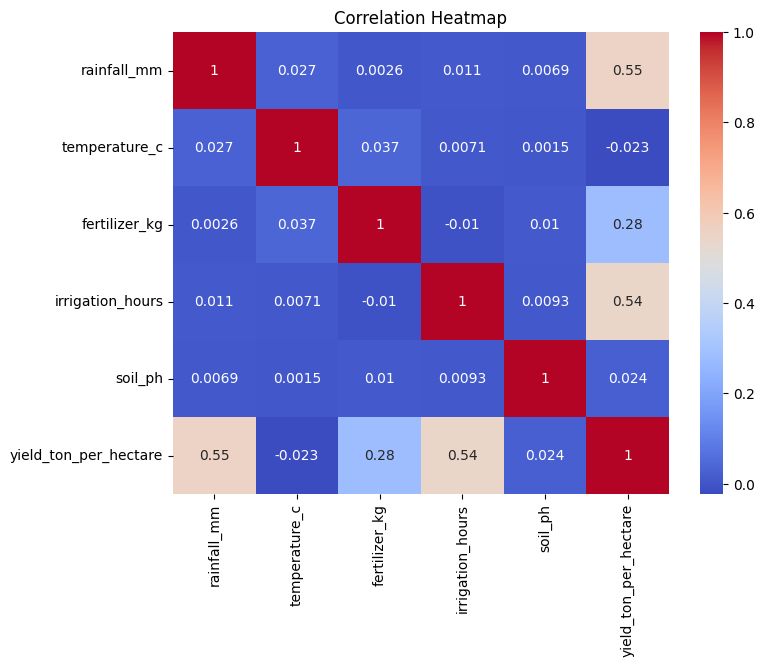

In [109]:
# Create a heatmap.

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [110]:
# Identify the top three features most correlated with crop yield.

corr_with_yield = corr_matrix['yield_ton_per_hectare'].sort_values(ascending=False)
corr_with_yield

,yield_ton_per_hectare
yield_ton_per_hectare,1.000000
rainfall_mm,0.553704
irrigation_hours,0.542664
fertilizer_kg,0.278043
soil_ph,0.024412
temperature_c,-0.022559


The top three features are rainfall_mm, irrigation_hours and fertilizer_kg

In [111]:
# Q10. Group-Based Analysis
# Calculate the average yield for:
# Each crop type

crop_avg = df.groupby('crop_type')['yield_ton_per_hectare'].mean()
crop_avg

,yield_ton_per_hectare
crop_type,
Cotton,4.607299
Maize,4.897143
Rice,5.494744
Soybean,5.173431
Wheat,4.989472


In [112]:
# Each soil type

soil_avg = df.groupby('soil_type')['yield_ton_per_hectare'].mean()
soil_avg

,yield_ton_per_hectare
soil_type,
Clay,5.134326
Loamy,5.366519
Sandy,4.588882


In [113]:
# Which crop and soil type have the highest average yield?

highest_crop = crop_avg.idxmax()
highest_crop_value = crop_avg.max()

highest_soil = soil_avg.idxmax()
highest_soil_value = soil_avg.max()

print("Highest Yield Crop:", highest_crop, highest_crop_value)
print("Highest Yield Soil:", highest_soil, highest_soil_value)

Highest Yield Crop: Rice 5.494744027303755
Highest Yield Soil: Loamy 5.366518987341772


In [114]:
# Part C: Data Preparation
# Q11. Feature Encoding
# The dataset contains categorical variables.
# Identify the categorical columns.

df.select_dtypes(include='object').columns

Index(['crop_type', 'soil_type'], dtype='object')

In [115]:
# Convert them into numerical form using One-Hot Encoding.

df_encoded = pd.get_dummies(df,
                            columns=['crop_type', 'soil_type'],
                            drop_first=True)

In [116]:
# Display the first five rows of the transformed dataset.

df_encoded.head()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


In [117]:
# Q12. Feature Selection
# Separate:
# Input features (X)
# Target variable (y)
# Specify which column is being used as the target variable.

X = df_encoded.drop(
    'yield_ton_per_hectare',
    axis=1
)
y = df_encoded['yield_ton_per_hectare']
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1500, 11)
y Shape: (1500,)


In [118]:
# Part D: Machine Learning
# Q13. Train-Test Split
# Split the dataset into: 80% Training Data and 20% Testing Data
# Display the shape of: X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1200, 11)
X_test shape: (300, 11)
y_train shape: (1200,)
y_test shape: (300,)


In [119]:
# Q14. Linear Regression Model
# Train a Linear Regression model.

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [120]:
# Display the model coefficients and intercept.

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)
print("Intercept:", model.intercept_)

              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5     crop_type_Maize     0.238931
6      crop_type_Rice     0.863993
7   crop_type_Soybean     0.481719
8     crop_type_Wheat     0.348474
9     soil_type_Loamy     0.302974
10    soil_type_Sandy    -0.490933
Intercept: 1.587132027736121


In [121]:
# Which feature has the highest positive coefficient?

top_feature = coefficients.loc[coefficients['Coefficient'].idxmax()]

print("Feature with highest positive coefficient:")
print(top_feature)

Feature with highest positive coefficient:
Feature        crop_type_Rice
Coefficient          0.863993
Name: 6, dtype: object
